In [1]:
import os 
import pandas as pd
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve, precision_recall_curve

In [7]:
medianomaly_rsna_test_dir = "/kaggle/input/datasets/thebeo182004/medianomaly-rsna/medi_anomaly/test"
normal_medianomaly_rsna_test_dir = os.path.join(medianomaly_rsna_test_dir, "normal")
abnormal_medianomaly_rsna_test_dir = os.path.join(medianomaly_rsna_test_dir, "abnormal")

In [3]:
inference_dir = "/kaggle/input/notebooks/thebeo182004/anomalyraddinov2-medianomaly-rsna-amap/medianomaly_rsna_amap/test"
normal_inference_dir = os.path.join(inference_dir, 'normal')
abnormal_inference_dir = os.path.join(inference_dir, 'abnormal')

**Query statistics of generated pixel-level anomaly maps (get percentiles instead of min/max to avoid outliers)**

In [27]:
# Danh sách để thu thập các pixel (đã lấy mẫu) từ tất cả các ảnh
sampled_pixels = []

# Tỷ lệ lấy mẫu (Sub-sampling stride)
# stride = 10 nghĩa là cứ 10 pixel thì lấy 1 pixel. Giúp giảm 10 lần dung lượng RAM.
stride = 10 

print("Đang thu thập phân phối pixel từ tập Normal...")
for amap_path in tqdm(os.listdir(normal_inference_dir)):
    amap = np.load(os.path.join(normal_inference_dir, amap_path), allow_pickle=True)['anomaly_map']
    # Kéo giãn thành mảng 1D và chỉ lấy các pixel cách đều nhau (stride)
    sampled_pixels.append(amap.ravel()[::stride])

print("Đang thu thập phân phối pixel từ tập Abnormal...")
for amap_path in tqdm(os.listdir(abnormal_inference_dir)):
    amap = np.load(os.path.join(abnormal_inference_dir, amap_path), allow_pickle=True)['anomaly_map']
    sampled_pixels.append(amap.ravel()[::stride])

print("Đang gộp dữ liệu và tính toán Bách phân vị...")
# Gộp tất cả các pixel lấy mẫu thành một mảng NumPy 1D khổng lồ
all_pixels_array = np.concatenate(sampled_pixels)

# Tính toán bách phân vị (Percentiles)
# Bạn có thể tinh chỉnh 0.1 và 99.9 thành 0.5 và 99.5 tùy thuộc vào độ gắt mong muốn
MIN_PERCENTILE = 0.1
MAX_PERCENTILE = 100 - MIN_PERCENTILE
ROBUST_MIN = np.percentile(all_pixels_array, MIN_PERCENTILE) 
ROBUST_MAX = np.percentile(all_pixels_array, MAX_PERCENTILE)

# Giải phóng bộ nhớ RAM
del sampled_pixels
del all_pixels_array

print(f"Robust Global Min (P_{MIN_PERCENTILE}): {ROBUST_MIN:.4f}")
print(f"Robust Global Max (P_{MAX_PERCENTILE}): {ROBUST_MAX:.4f}")

Đang thu thập phân phối pixel từ tập Normal...


  0%|          | 0/1000 [00:00<?, ?it/s]

Đang thu thập phân phối pixel từ tập Abnormal...


  0%|          | 0/1000 [00:00<?, ?it/s]

Đang gộp dữ liệu và tính toán Bách phân vị...
Robust Global Min (P_0.1): 0.0000
Robust Global Max (P_99.9): 0.1022


**Find the best optimal anomaly score threshold to separate normal and abnormal cases**

In [5]:
def find_optimal_thresholds(y_true, y_scores):
    # 1. Tìm threshold theo Youden's J statistic (ROC curve)
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
    youden_j = tpr - fpr
    optimal_idx_roc = np.argmax(youden_j)
    optimal_threshold_youden = roc_thresholds[optimal_idx_roc]
    
    print(f"--- Tối ưu theo Youden's J (ROC Curve) ---")
    print(f"Threshold: {optimal_threshold_youden:.4f}")
    print(f"TPR (Sensitivity): {tpr[optimal_idx_roc]:.4f}")
    print(f"FPR: {fpr[optimal_idx_roc]:.4f}\n")

    # 2. Tìm threshold tối đa hóa F1-Score (Precision-Recall curve)
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)
    
    # Tránh chia cho 0
    numerator = 2 * (precision * recall)
    denominator = (precision + recall)
    f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
    
    # Lấy index của F1 lớn nhất (pr_thresholds có ít hơn precision/recall 1 phần tử)
    optimal_idx_pr = np.argmax(f1_scores)
    
    # Xử lý an toàn độ dài của array
    if optimal_idx_pr < len(pr_thresholds):
        optimal_threshold_f1 = pr_thresholds[optimal_idx_pr]
    else:
        optimal_threshold_f1 = pr_thresholds[-1]
        
    print(f"--- Tối ưu hóa theo F1-Score tối đa ---")
    print(f"Threshold: {optimal_threshold_f1:.4f}")
    print(f"Max F1-Score: {f1_scores[optimal_idx_pr]:.4f}")
    print(f"Precision: {precision[optimal_idx_pr]:.4f} | Recall: {recall[optimal_idx_pr]:.4f}\n")
    
    # 3. Tìm threshold với ràng buộc lâm sàng: Cố định Sensitivity >= 95%
    target_sensitivity = 0.95
    # Tìm index đầu tiên mà TPR >= 95% (vì thresholds trong roc_curve sắp xếp giảm dần)
    idx_95_sens = np.where(tpr >= target_sensitivity)[0][0]
    threshold_95_sens = roc_thresholds[idx_95_sens]
    
    print(f"--- Ràng buộc lâm sàng: Sensitivity >= 95% ---")
    print(f"Threshold: {threshold_95_sens:.4f}")
    print(f"TPR thực tế: {tpr[idx_95_sens]:.4f}")
    print(f"FPR phải đánh đổi: {fpr[idx_95_sens]:.4f}\n")

    return {
        "youden": optimal_threshold_youden,
        "f1_max": optimal_threshold_f1,
        "sens_95": threshold_95_sens
    }

In [41]:
gt_labels = []
anomaly_scores = []

for amap_path in tqdm(os.listdir(normal_inference_dir)):
    score = np.load(os.path.join(normal_inference_dir, amap_path), allow_pickle=True)['anomaly_score']
    anomaly_scores.append(score)
    gt_labels.append(0)

for amap_path in tqdm(os.listdir(abnormal_inference_dir)):
    score = np.load(os.path.join(abnormal_inference_dir, amap_path), allow_pickle=True)['anomaly_score']
    anomaly_scores.append(score)
    gt_labels.append(1)

optimal_threshold = find_optimal_thresholds(gt_labels, anomaly_scores)['youden']

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

--- Tối ưu theo Youden's J (ROC Curve) ---
Threshold: 0.0492
TPR (Sensitivity): 0.8690
FPR: 0.1190

--- Tối ưu hóa theo F1-Score tối đa ---
Threshold: 0.0491
Max F1-Score: 0.8744
Precision: 0.8788 | Recall: 0.8700

--- Ràng buộc lâm sàng: Sensitivity >= 95% ---
Threshold: 0.0438
TPR thực tế: 0.9500
FPR phải đánh đổi: 0.2980



**Iterate through normal and abnormal dirs, determine which cases are true positive, false positive, true negative and false negative based on given optimal threshold and organize them in appropriate list with their metadata, including image file path, anomaly map, anomaly score and grouth truth annotations if possible**

In [9]:
annotations_df = pd.read_csv("/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv")
annotations_df.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [12]:
def get_annotations(img_id):
    patient_rows = annotations_df[annotations_df['patientId'] == img_id]

    if patient_rows.empty:
        return None, "Không tìm thấy bệnh nhân này"
        
    if (patient_rows['Target'] == 0).all():
        print("Bệnh nhân hoàn toàn khỏe mạnh")
        return [],

    boxes = list(zip(patient_rows['x'], 
                     patient_rows['y'], 
                     patient_rows['width'], 
                     patient_rows['height']))

    return boxes

get_annotations("00436515-870c-4b36-a041-de91049b9ab4")

[(264.0, 152.0, 213.0, 379.0), (562.0, 152.0, 256.0, 453.0)]

In [8]:
true_negatives = []
false_positives = []

for path in tqdm(os.listdir(normal_inference_dir)):
    saved_data = np.load(os.path.join(normal_inference_dir, path), allow_pickle=True)
    img_id = Path(path).stem
    anomaly_map, anomaly_score = saved_data['anomaly_map'], saved_data['anomaly_score']

    if anomaly_score <= optimal_threshold: #true negatives
        true_negatives.append((os.path.join(normal_medianomaly_rsna_test_dir, img_id + ".png"), 
                              anomaly_map, anomaly_score))
    else:
        false_positives.append((os.path.join(normal_medianomaly_rsna_test_dir, img_id + ".png"), 
                              anomaly_map, anomaly_score))

  0%|          | 0/1000 [00:00<?, ?it/s]

In [14]:
true_positives = []
false_negatives = []

for path in tqdm(os.listdir(abnormal_inference_dir)):
    saved_data = np.load(os.path.join(abnormal_inference_dir, path), allow_pickle=True)
    img_id = Path(path).stem
    anomaly_map, anomaly_score = saved_data['anomaly_map'], saved_data['anomaly_score']
    gt_boxes = get_annotations(img_id)
    
    if anomaly_score > optimal_threshold: #true positives
        true_positives.append((os.path.join(abnormal_medianomaly_rsna_test_dir, img_id + ".png"), 
                              anomaly_map, anomaly_score, gt_boxes))
    else: # false negatives
        false_negatives.append((os.path.join(abnormal_medianomaly_rsna_test_dir, img_id + ".png"), 
                              anomaly_map, anomaly_score, gt_boxes))

  0%|          | 0/1000 [00:00<?, ?it/s]

In [16]:
len(true_negatives), len(false_positives), len(true_positives), len(false_negatives)

(881, 119, 868, 132)

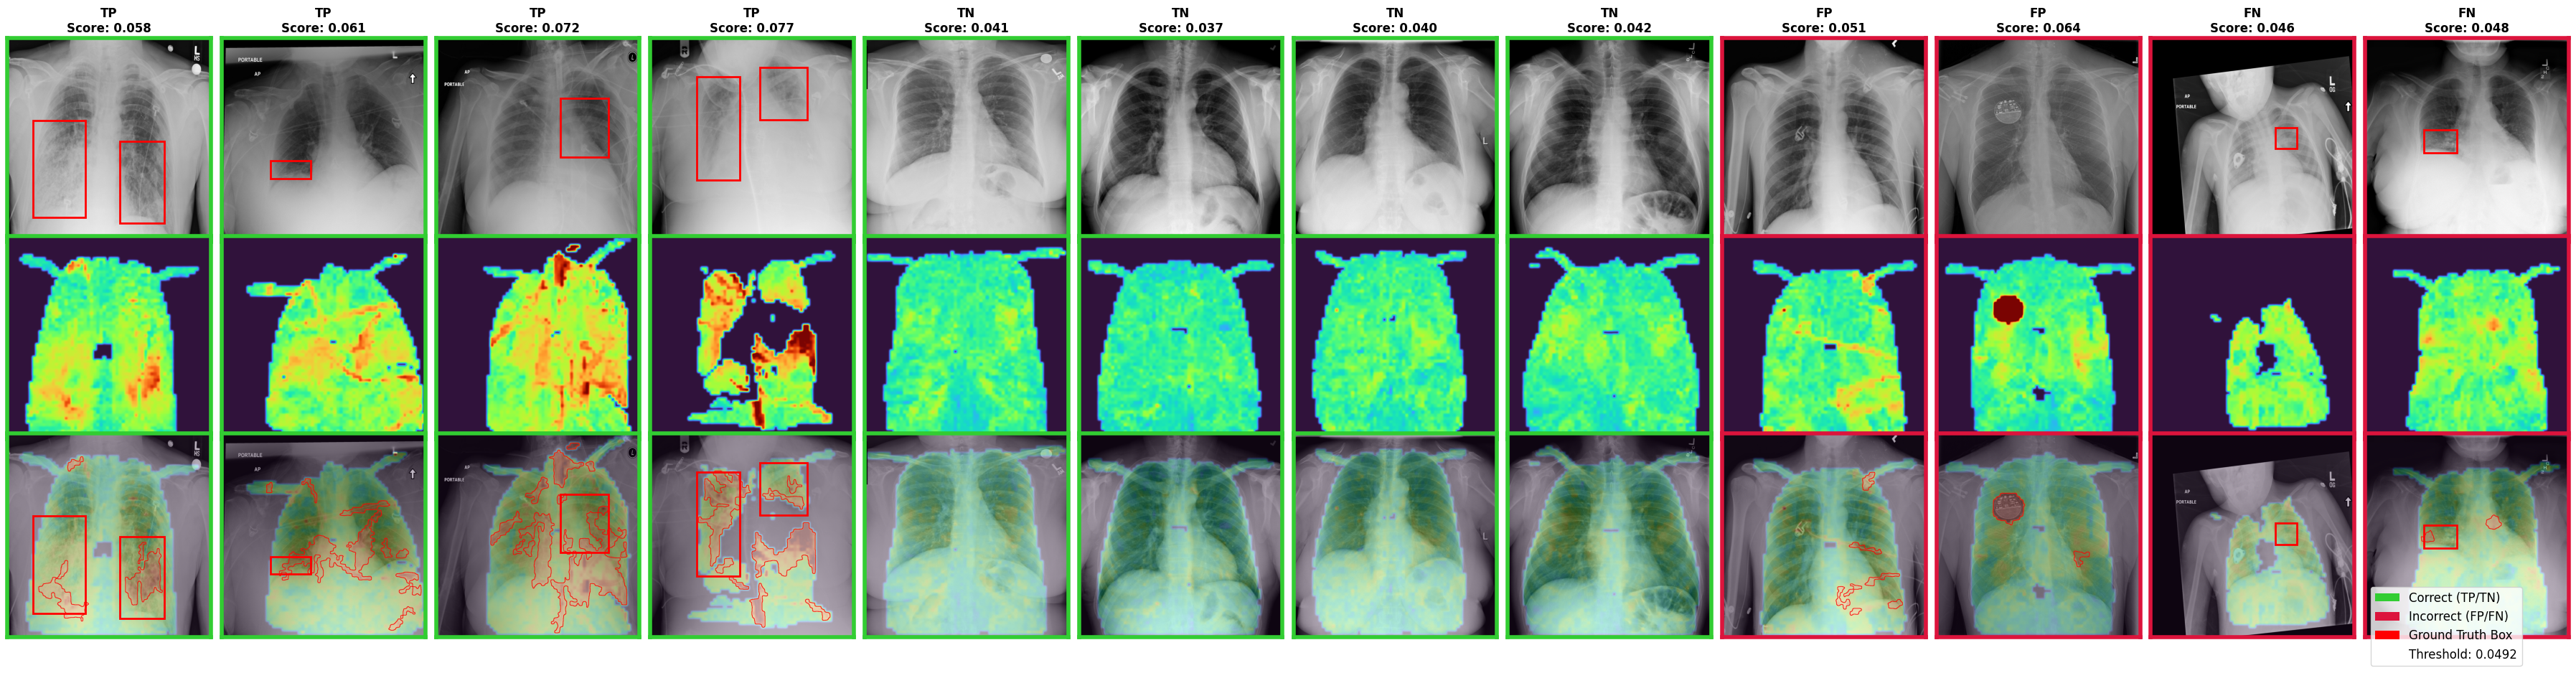

In [45]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import matplotlib.patches as patches

def plot_anomaly_grid(data_dict, robust_min, robust_max, optimal_threshold, gamma_scale=0.8, threshold_val=0.6, morph_kernel_size=5):
    """
    Trực quan hóa Grid kèm Optimal Threshold và Legend.
    """
    ordered_keys = ['TP', 'TN', 'FP', 'FN']
    samples = []
    for k in ordered_keys:
        samples.extend(data_dict[k][:4 if k in ['TP', 'TN'] else 2])
    
    fig, axes = plt.subplots(3, 12, figsize=(36, 10))
    
    for col, sample_data in enumerate(samples):
        # 1. Giải nén và Load ảnh
        if len(sample_data) == 4:
            img_path, amap, score, gt_boxes = sample_data
        else:
            img_path, amap, score = sample_data
            gt_boxes = None
            
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        h, w = img.shape
        
        # 2. Chuẩn hóa & Gamma Correction
        norm_amap = np.clip((amap - robust_min) / (robust_max - robust_min + 1e-8), 0, 1)
        norm_amap = np.power(np.squeeze(norm_amap), gamma_scale) 
        
        # 3. Threshold Mask & Morphology
        mask = (norm_amap >= threshold_val).astype(np.uint8) * 255
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        min_area = 0.001 * h * w 
        valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
        
        # 4. Overlay
        heatmap = cv2.applyColorMap((norm_amap * 255).astype(np.uint8), cv2.COLORMAP_TURBO)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(0.7 * (img_rgb/255.0) + 0.3 * heatmap, 0, 1)
        
        overlay_disp = (overlay * 255).astype(np.uint8)
        if valid_contours:
            cv2.drawContours(overlay_disp, valid_contours, -1, (255, 0, 0), 2)
        
        # 5. Vẽ lên Grid
        case_type = [k for k, v in data_dict.items() if sample_data in v][0]
        border_color = 'limegreen' if case_type in ['TP', 'TN'] else 'crimson'
        
        for row in range(3):
            ax = axes[row, col]
            if row == 0:
                ax.imshow(img_rgb, cmap='gray')
                if gt_boxes: _draw_boxes(ax, gt_boxes, 'red')
            elif row == 1:
                ax.imshow(norm_amap, cmap='turbo', vmin=0, vmax=1)
            else:
                ax.imshow(overlay_disp)
                if gt_boxes: _draw_boxes(ax, gt_boxes, 'red')
                
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color); spine.set_linewidth(4)
        
        axes[0, col].set_title(f"{case_type}\nScore: {score:.3f}", fontsize=12, fontweight='bold')

    # THÊM LEGEND (Góc dưới phải)
    legend_elements = [
        patches.Patch(facecolor='limegreen', label='Correct (TP/TN)'),
        patches.Patch(facecolor='crimson', label='Incorrect (FP/FN)'),
        patches.Patch(facecolor='red', label='Ground Truth Box'),
        patches.Patch(facecolor='none', edgecolor='none', label=f'Threshold: {optimal_threshold:.4f}')
    ]
    fig.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True, bbox_to_anchor=(0.98, 0.02))

    # THÊM Optimal Threshold info
    # fig.suptitle(f"Anomaly Detection Visualization | Optimal Threshold: {optimal_threshold:.4f}", fontsize=16, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def _draw_boxes(ax, bboxes, color):
    for (x, y, w, h) in bboxes:
        rect = plt.Rectangle((x, y), w, h, fill=False, color=color, linewidth=2)
        ax.add_patch(rect)

# Gọi hàm với tham số mới
plot_anomaly_grid(
    {
        'TP': true_positives,
        'TN': true_negatives,
        'FP': false_positives,
        'FN': false_negatives
    },
    ROBUST_MIN, ROBUST_MAX, 
    optimal_threshold=optimal_threshold # Giá trị threshold của bạn
)